In [10]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [6]:
df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
#data cleaning

df.info()

df['Order Date'] = pd.to_datetime(df['Order Date'])

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


EDA
SALES By Region

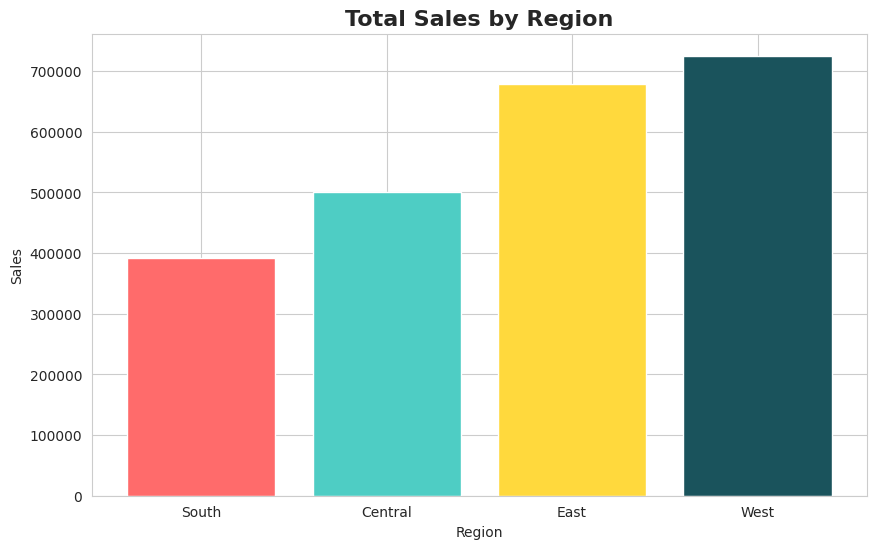

In [13]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values()

colors = ["#FF6B6B", "#4ECDC4", "#FFD93D", "#1A535C"]

plt.bar(region_sales.index, region_sales.values, color=colors)

plt.title("Total Sales by Region", fontsize=16, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

Sales by category

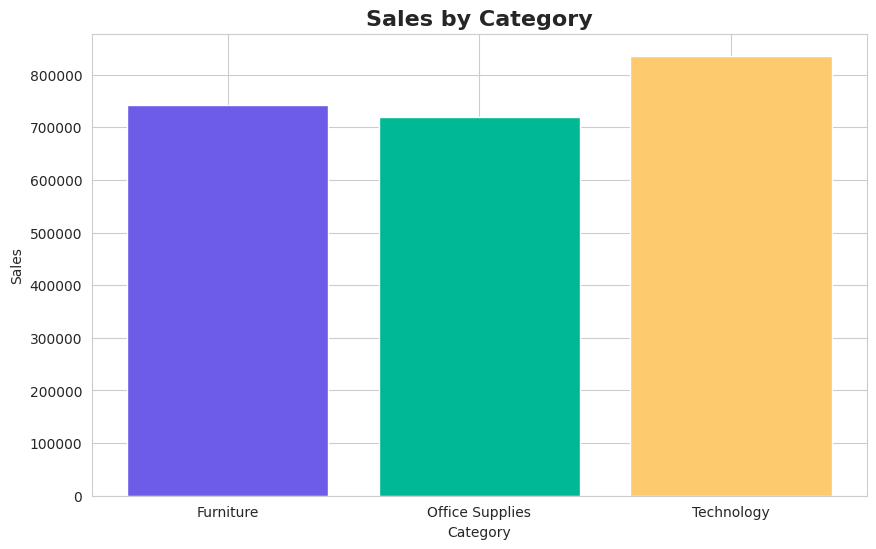

In [14]:
category_sales = df.groupby("Category")["Sales"].sum()

colors = ["#6C5CE7", "#00B894", "#FDCB6E"]

plt.bar(category_sales.index, category_sales.values, color=colors)

plt.title("Sales by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

Monthly sales trend

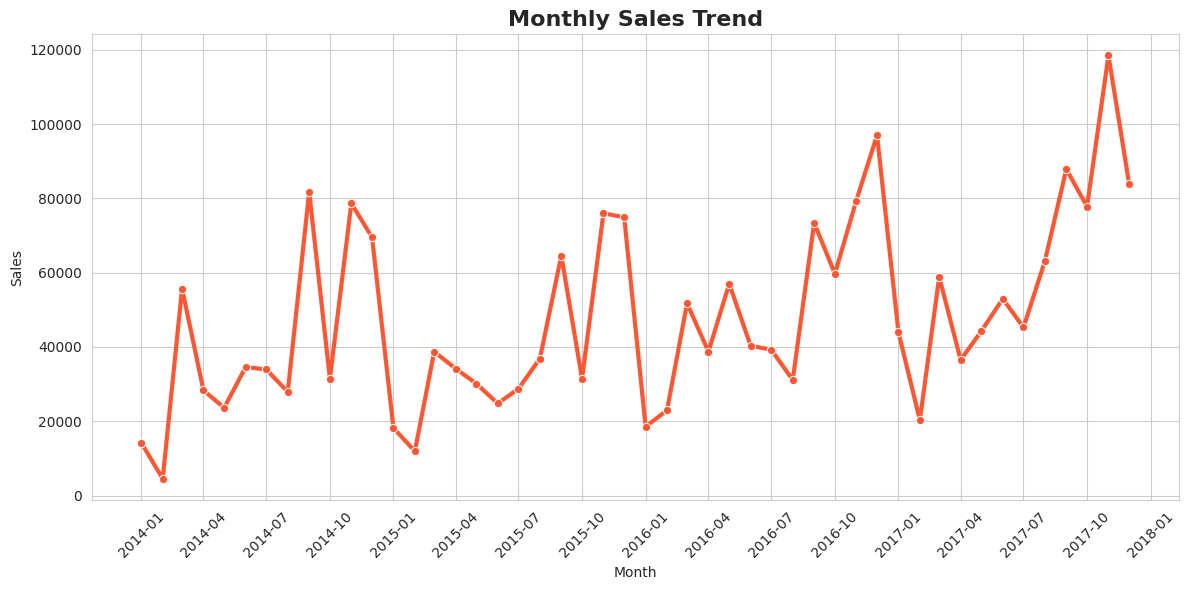

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import pandas as pd # Import pandas for pd.to_datetime

plt.figure(figsize=(12,6))

sns.lineplot(x=pd.to_datetime(monthly_sales.index),
             y=monthly_sales.values,
             marker="o",
             color="#ff5733",
             linewidth=3)

plt.title("Monthly Sales Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales")

# show tick every 3 months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Top 10 products

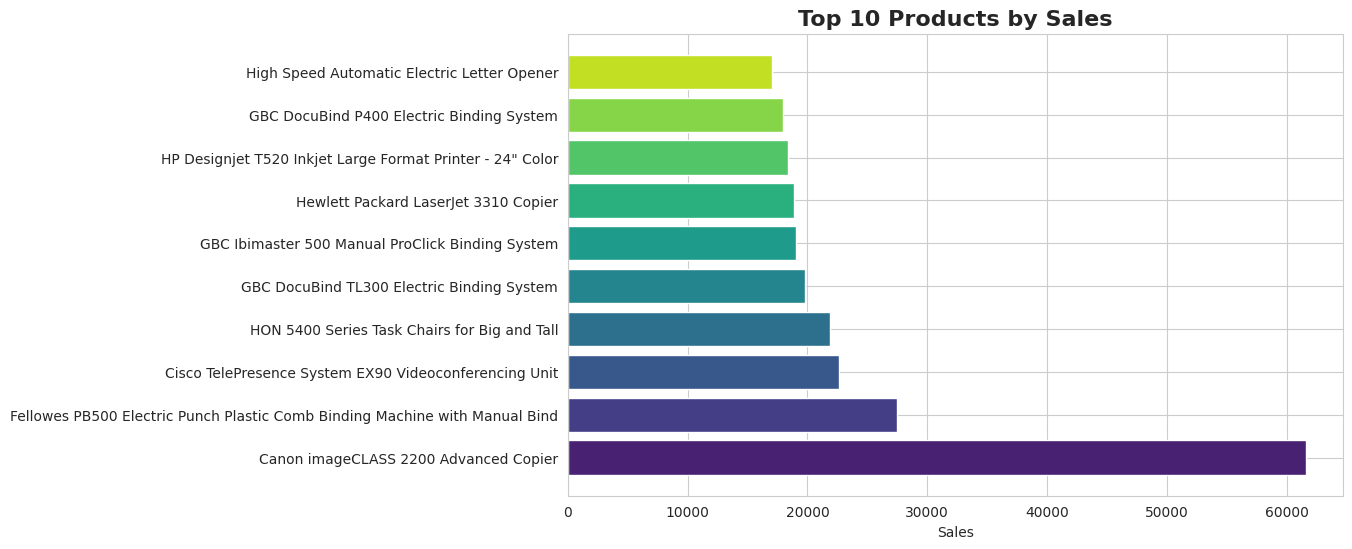

In [17]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

colors = sns.color_palette("viridis", 10)

plt.barh(top_products.index, top_products.values, color=colors)

plt.title("Top 10 Products by Sales", fontsize=16, fontweight="bold")
plt.xlabel("Sales")

plt.show()

Sales vs profit (scatter plot)

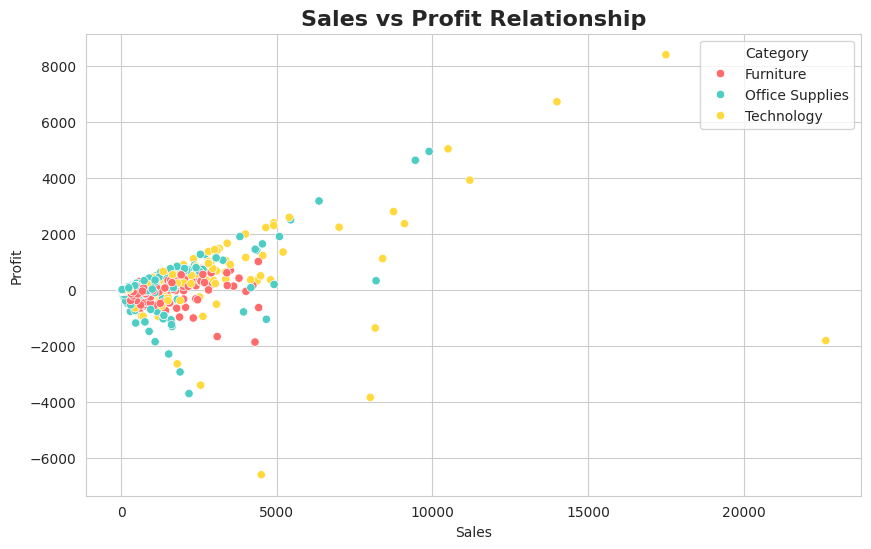

In [18]:
sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Category",
    palette=["#FF6B6B", "#4ECDC4", "#FFD93D"]
)

plt.title("Sales vs Profit Relationship", fontsize=16, fontweight="bold")

plt.show()

Sales heat map

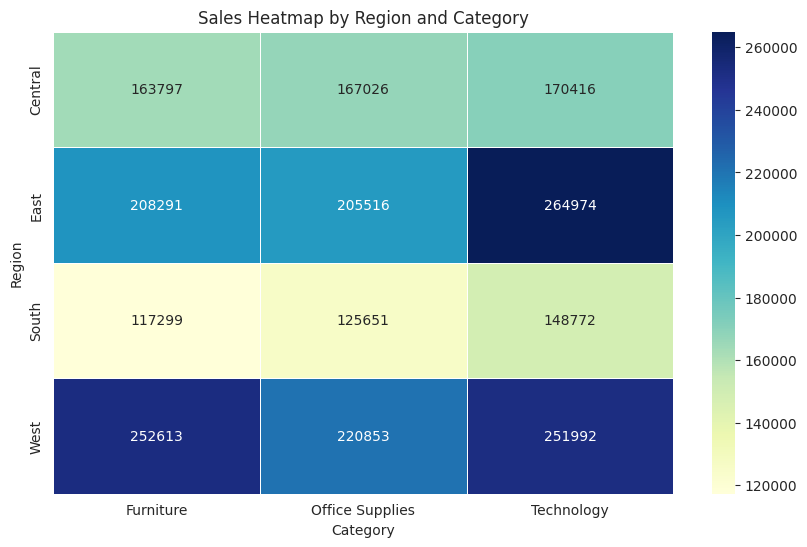

In [19]:
pivot = df.pivot_table(values="Sales", index="Region", columns="Category", aggfunc="sum")

sns.heatmap(pivot,
            annot=True,
            fmt=".0f",
            cmap="YlGnBu",
            linewidths=0.5)

plt.title("Sales Heatmap by Region and Category")

plt.show()

Sales Forecasting

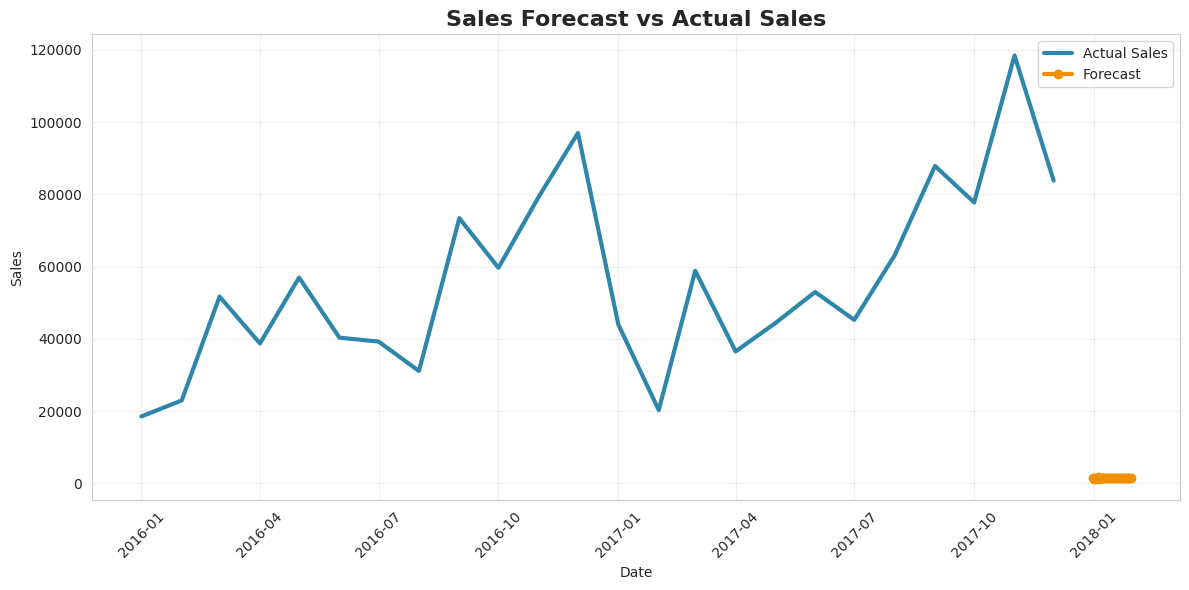

In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Import mdates

# Plot only last 24 months for clarity
actual_recent = monthly_sales[-24:]

plt.figure(figsize=(12,6))

# Convert datetime indices to matplotlib's internal date format
actual_recent_x = mdates.date2num(actual_recent.index)
forecast_x = mdates.date2num(forecast.index)

plt.plot(
    actual_recent_x,
    actual_recent.values,
    label="Actual Sales",
    color="#2E86AB",
    linewidth=3
)

plt.plot(
    forecast_x,
    forecast.values,
    label="Forecast",
    color="#F18F01",
    linewidth=3,
    marker="o"
)

plt.title("Sales Forecast vs Actual Sales", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.legend()
plt.grid(alpha=0.3)

# Apply date formatter to the x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

plt.tight_layout()

plt.show()

Sales growth rate analysis

/tmp/ipykernel_566/1494177595.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = sales_ts.resample('M').sum()


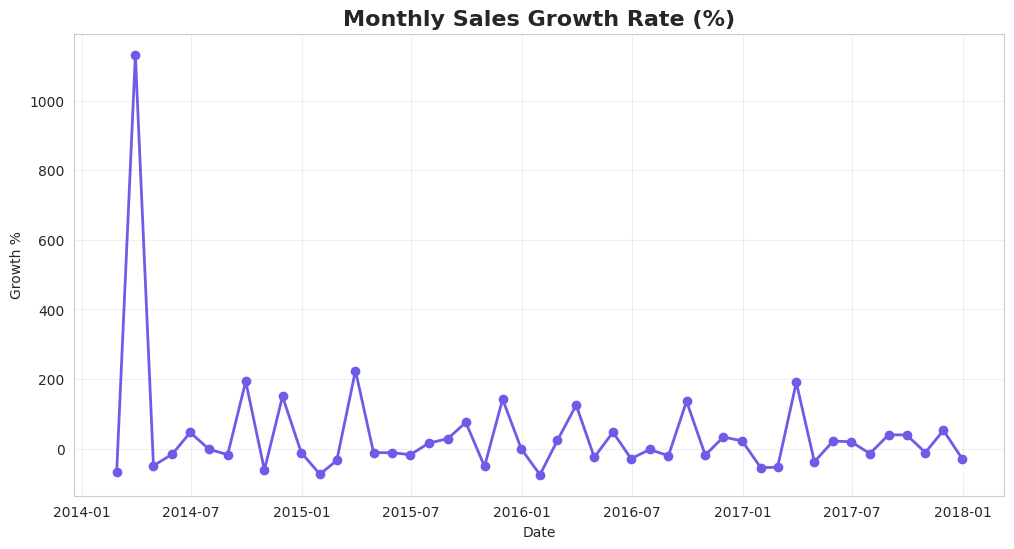

In [32]:
monthly_sales = sales_ts.resample('M').sum()

growth_rate = monthly_sales.pct_change() * 100

plt.figure(figsize=(12,6))
plt.plot(growth_rate, marker='o', color='#6C5CE7', linewidth=2)

plt.title("Monthly Sales Growth Rate (%)", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Growth %")

plt.grid(alpha=0.3)
plt.show()

What this model demonstrates in project:

1) supervised machine learning
2) regression modeling
3) categorical feature encoding
4) model evaluation (MAE, R²)
5) feature importance interpretation

R2 Score: 0.09574312109995564


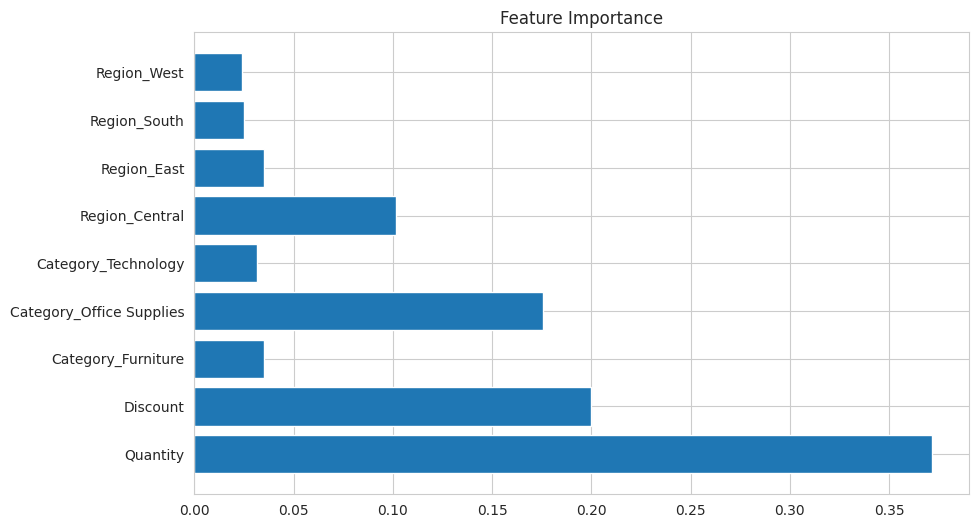

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')

X = pd.get_dummies(df[['Category','Region','Quantity','Discount']])
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

plt.barh(X.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.show()